In [111]:
import numpy as np
from hackrf import HackRF
import time
import matplotlib.pyplot as plt
from datetime import datetime
import os
from scipy.signal import stft

In [112]:
# Setup save directory and timestamped filename for binary .dat (complex64 interleaved)
main_dir = "/home/cubesat/Cubesat/Proj1/data/iq"

# get newest file
dat_file = max(
    (os.path.join(main_dir, f) for f in os.listdir(main_dir)),
    key=os.path.getmtime
)

fs = 5_000_000               # sample rate (Hz)
delta_f = -100_000           # TX - RX (Hz). For TX=1.0 MHz, RX=1.1 MHz => -100 kHz

# --- Load interleaved int8 IQ: I0,Q0,I1,Q1,... ---
raw = np.fromfile(dat_file, dtype=np.int8)

# Convert to complex64
iq = raw[0::2].astype(np.float32) + 1j * raw[1::2].astype(np.float32)

# remove DC offset
iq = iq - np.mean(iq)


Attempt to plot original signal

using
r(t) = e^(...) * s_bb(t)

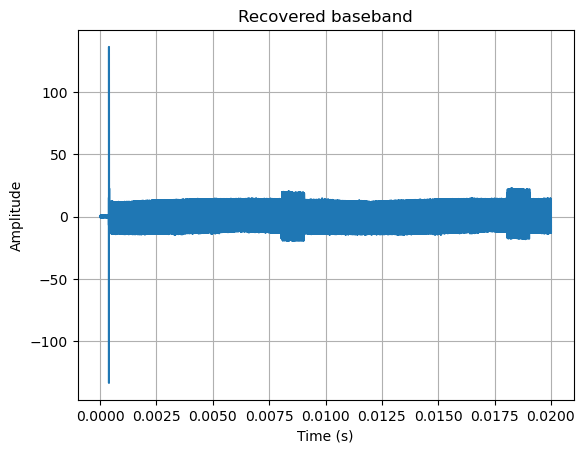

In [113]:

# De-rotation
test_samples = 1_000_00
n = np.arange(test_samples, dtype=np.float32)
rot = np.exp(-1j * 2*np.pi * delta_f * n / fs)
s_hat = iq[:test_samples] * rot

# Plot recovered signal
plt.figure()
t = n / fs
plt.plot(t, np.real(s_hat))
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Recovered baseband")
plt.grid(True)
plt.show()




In [114]:

# PRINT size 
print("Raw size:", raw.size)

# compare raw first 20 to iq first 10
print("Raw first 20:", raw[:20])
print("IQ first 10:", iq[:10])

Raw size: 10000000
Raw first 20: [ 2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2]
IQ first 10: [-0.20705152+0.38575053j -0.20705152+0.38575053j -0.20705152+0.38575053j
 -0.20705152+0.38575053j -0.20705152+0.38575053j -0.20705152+0.38575053j
 -0.20705152+0.38575053j -0.20705152+0.38575053j -0.20705152+0.38575053j
 -0.20705152+0.38575053j]


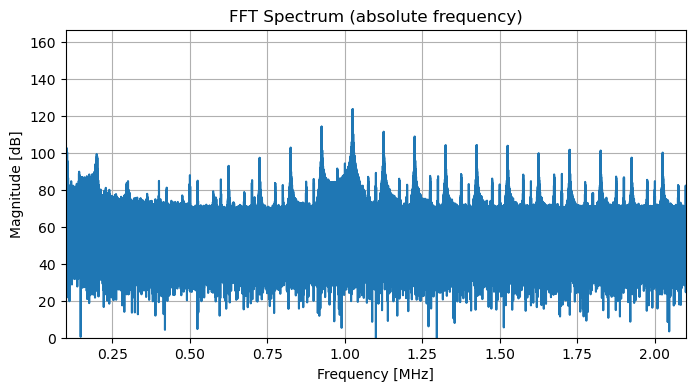

In [115]:
# --- FFT ---
center_freq = 1.1e6  # Center frequency in Hz (absolute)
sample_rate =5_000_000  # Sample rate in Hz
N = len(iq)
spectrum = np.fft.fftshift(np.fft.fft(iq))

freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/sample_rate))  # baseband frequencies (Hz)
# Convert to absolute frequency by adding center_freq
freqs_abs = center_freq + freqs

# --- Plot ---
plt.figure(figsize=(8,4))
plt.plot(freqs_abs/1e6, 20*np.log10(np.abs(spectrum) + 1e-6))
plt.title("FFT Spectrum (absolute frequency)")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Magnitude [dB]")
plt.grid(True)

# set x-axis range example: center_freq +/- 1 MHz
plt.xlim((center_freq - 1e6)/1e6, (center_freq + 1e6)/1e6)
plt.ylim(0, np.max(20*np.log10(np.abs(spectrum))) + 10)
plt.show()


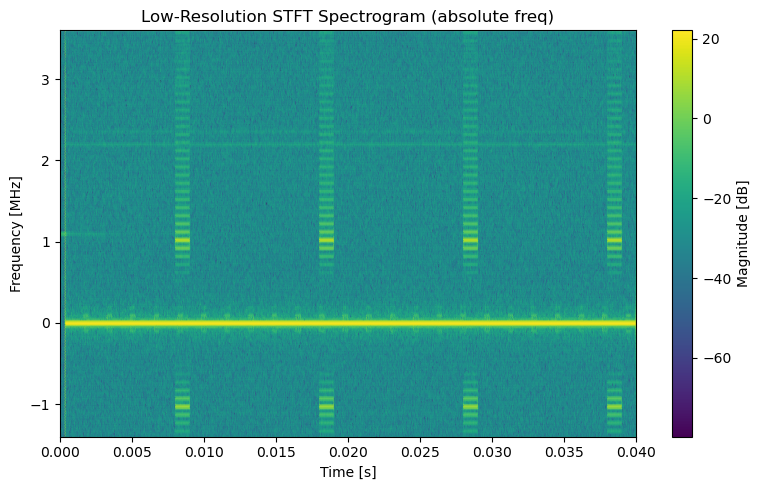

STFT shape = (256, 1564), time frames = 1564, freq bins = 256


In [116]:
from scipy.signal import stft
from numpy.fft import fftshift
import matplotlib.pyplot as plt
import numpy as np

# Downsample and shorten for speed
# iq_ds = iq[start_idx-100_000:start_idx+400_000]      # only first 200k samples, every 20th
iq_ds = iq[:200_000]
fs = sample_rate         # adjust sample rate

# STFT parameters
nperseg = 256
noverlap = nperseg // 2
window = 'hann'

# Compute STFT
f, t, Zxx = stft(iq_ds, fs=fs, window=window, nperseg=nperseg,
                 noverlap=noverlap, return_onesided=False)

# Shift and convert to dB
Zxx_shift = fftshift(Zxx, axes=0)
f_shift = fftshift(f)
# Convert to absolute frequency by adding center_freq (if set above)
f_shift_abs = center_freq + f_shift
Sxx = 20 * np.log10(np.abs(Zxx_shift) + 1e-12)

# Plot
plt.figure(figsize=(8,5))
plt.pcolormesh(t, f_shift_abs/1e6, Sxx, shading='gouraud', cmap='viridis')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [MHz]')
plt.title('Low-Resolution STFT Spectrogram (absolute freq)')
plt.colorbar(label='Magnitude [dB]')
# Set y-limits centered on center_freq if available
plt.ylim((center_freq - fs/2)/1e6, (center_freq + fs/2)/1e6)
plt.tight_layout()
plt.show()   

print(f"STFT shape = {Sxx.shape}, time frames = {len(t)}, freq bins = {len(f)}")


In [117]:
from scipy.signal import stft
from numpy.fft import fftshift
import matplotlib.pyplot as plt
import numpy as np

fs = 5_000_000  # Hz
symbol_rate = 100_000  # Hz
symbols_per_block = 1000 # from the transmitted waveform, 100 sym on, 900 sym off
fc = 1.1e6  # Hz
ftone = 1e6  # Hz
samples_per_block = fs // symbol_rate * symbols_per_block

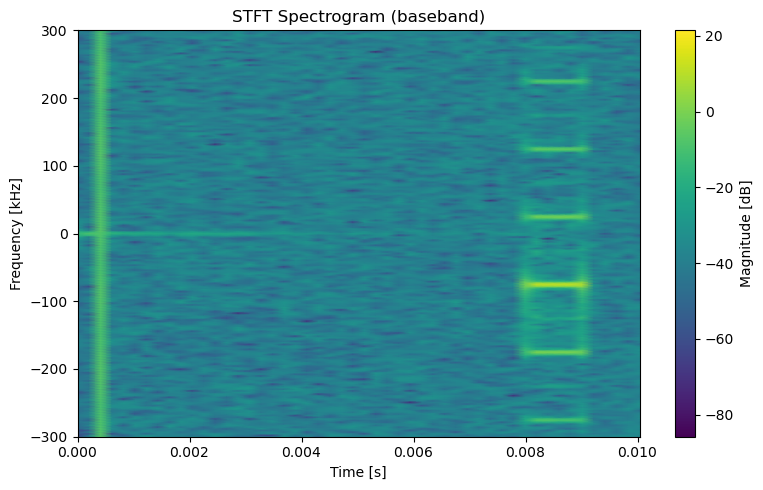

STFT shape = (2048, 50), time frames = 50, freq bins = 2048


In [118]:
# Shorten for speed
iq_ds = iq[:samples_per_block]
fs = sample_rate

# STFT parameters
nperseg = 2048
noverlap = nperseg // 2
window = 'hann'

# Compute STFT
f, t, Zxx = stft(
    iq_ds,
    fs=fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
    return_onesided=False
)

# Shift zero frequency to center
Zxx_shift = fftshift(Zxx, axes=0)
f_shift = fftshift(f)

# Magnitude in dB
Sxx = 20 * np.log10(np.abs(Zxx_shift) + 1e-12)

# Plot (BASEBAND frequency axis)
plt.figure(figsize=(8, 5))
plt.pcolormesh(t, f_shift / 1e3, Sxx, shading='gouraud', cmap='viridis')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [kHz]')
plt.title('STFT Spectrogram (baseband)')
plt.colorbar(label='Magnitude [dB]')
plt.ylim(-300, 300)   # optional zoom around DC
plt.tight_layout()
plt.show()

print(f"STFT shape = {Sxx.shape}, time frames = {len(t)}, freq bins = {len(f)}")

Power correlator to get start_idx

First, we must mix the signal
r(t) - recieved signal shown above
s_bb(t) - baseband 
delta f = f_rxcarrier - f_txcarrier (here it is 0.1 mhz)

Key formula
r(t) = e^(-2pijt * (deltaf)) s_bb(t)

so obtain s_bb(t) by multiplying by 

In [119]:
iq_block = iq[:samples_per_block] # take one block of samples (1000 symbols) 100 on 900 off

# -- shift energy near ftone to 0 Hz --
f_offset = ftone - fc  # Hz
n = np.arange(len(iq_block), dtype=np.float64)
lo = np.exp(-1j * 2*np.pi * f_offset * n / fs)
bb = iq_block * lo

print("Mean power:", np.mean(np.abs(bb)**2))
print("First 5 samples magnitude:", np.abs(bb[:5]))

sps = int(fs / symbol_rate)   # 50
M = sps                       # moving-average length (try 50)

# Low-pass filter via moving average
h = np.ones(M, dtype=np.float64) / M
bb_lp = np.convolve(bb, h, mode="same")

print()
print("LP mean power:", np.mean(np.abs(bb_lp)**2))
print("First 5 LP samples magnitude:", np.abs(bb_lp[:5]))

Mean power: 173.6051458691491
First 5 samples magnitude: [0.43780567 0.43780567 0.43780567 0.43780567 0.43780567]

LP mean power: 1.119712902742947
First 5 LP samples magnitude: [0.12241486 0.12147603 0.12006688 0.11819329 0.11586312]


Plot to see shifted baseband

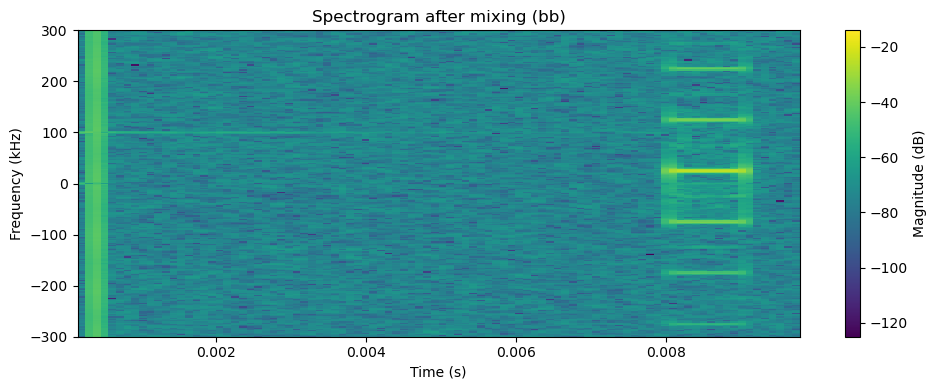

In [120]:

f, t, Sxx = spectrogram(
    bb,
    fs=fs,
    window="hann",
    nperseg=2048,
    noverlap=1536,
    return_onesided=False,
    scaling="density",
    mode="magnitude",
)

# Shift zero freq to center
Sxx = np.fft.fftshift(Sxx, axes=0)
f = np.fft.fftshift(f)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f / 1e3, 20*np.log10(Sxx + 1e-12), shading="auto")
plt.colorbar(label="Magnitude (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (kHz)")
plt.title("Spectrogram after mixing (bb)")
plt.ylim(-300, 300)   # zoom around DC
plt.tight_layout()
plt.show()


In [121]:
# Step 1: Calculate power of low-pass filtered signal
p = np.abs(bb_lp)**2

# Step 2: Moving average to smooth power
smooth_time_s = 0.0002
M = max(1, int(smooth_time_s * fs))

h = np.ones(M, dtype=np.float64) / M
p_smooth = np.convolve(p, h, mode="same")

In [122]:
# Step 3: noise threshold (from chatgpt)
noise_med = np.median(p_smooth)
mad = np.median(np.abs(p_smooth - noise_med)) + 1e-12
sigma_hat = 1.4826 * mad

k = 8.0
thr = noise_med + k * sigma_hat

min_on_time_s = 0.0003
L = max(1, int(min_on_time_s * fs))

above = p_smooth > thr
run = np.convolve(above.astype(np.int32), np.ones(L, dtype=np.int32), mode="same")
start_idx = int(np.argmax(run >= L)) if np.any(run >= L) else None

NOTE I WANT TO COME BACK HERE AND MAKE CLEANER Calc

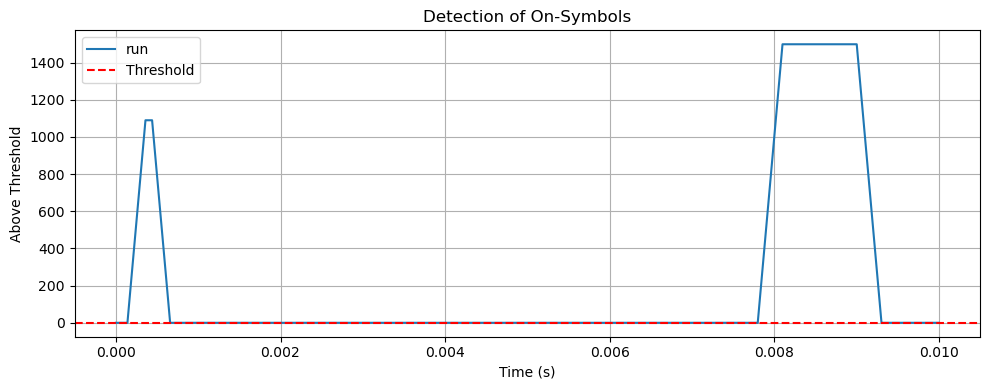

In [123]:
#plot above
t = np.arange(len(p_smooth)) / fs
plt.figure(figsize=(10, 4))
plt.plot(t, run, label="run")
plt.axhline(thr, color="red", linestyle="--", label="Threshold")
plt.xlabel("Time (s)")
plt.ylabel("Above Threshold")
plt.title("Detection of On-Symbols")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

No delay actually

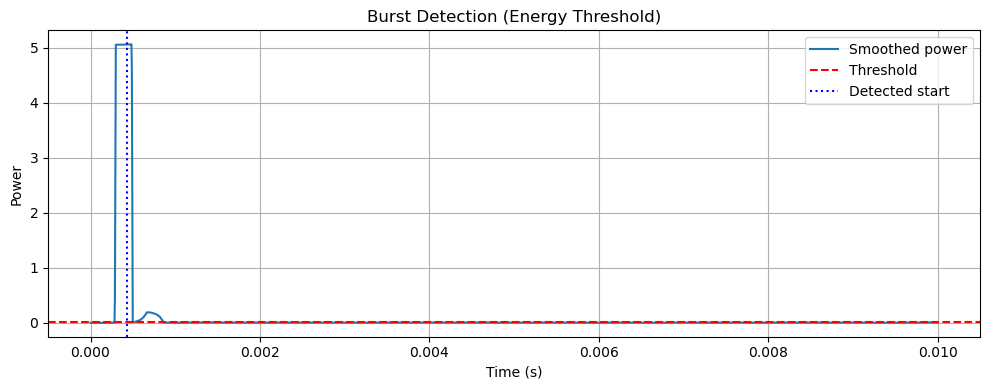

In [110]:
t = np.arange(len(p_smooth)) / fs

plt.figure(figsize=(10, 4))
plt.plot(t, p_smooth, label="Smoothed power")
plt.axhline(thr, color="r", linestyle="--", label="Threshold")

start_time = start_idx / fs if start_idx is not None else None
plt.axvline(start_time, color="b", linestyle=":", label="Detected start")

plt.xlabel("Time (s)")
plt.ylabel("Power")
plt.title("Burst Detection (Energy Threshold)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()